In [288]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

## Load database

In [289]:
pd.set_option('display.max_columns', None)
df = pd.read_csv("../app/database/Car Sales.xlsx - car_data.csv")
df.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


# Application and use cases

## 1 )Market Analysis:
### Evaluate overall trends and regional variations in car sales to assess manufacturer performance, model preferences, and demographic insights.
## 2) Seasonal Patterns and Competitor Analysis:
### Investigate seasonal and cyclical patterns in sales.
## 3) Forecasting and Predictive Analysis
### Use historical data for forecasting and predict future market trends. Support marketing, advertising, and investment decisions based on insights.
## 4) Supply Chain and Inventory Optimization:
### Provide valuable data for stakeholders in the automotive industry.

In [290]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer_No      23906 non-null  object
 13  Body Style     23906 non-null  object
 14  Phone          23906 non-null  int64 
 15  Dealer_Region  23906 non-null  object
dtypes: int64(3), object(13)
memory usage: 2.9+ MB


## Feature engineering

In [291]:
# Remove ($) in the price column and convert it to float
df['Price'] = df['Price ($)'].astype(float)
df.drop(columns=['Price ($)'], inplace=True)

# Calculate USD Price into IDR Price
df['Price'] = df['Price'] * 17990

# Stabilize column of Annual Income fetching to Price because the column of Annual Income is not stable, so we will use Price as a reference to calculate Annual Income
df.rename(columns={'Annual Income': 'Income_Customer'}, inplace=True)
df['Income_Customer'] = df['Income_Customer'].astype(float) * 17990

In [292]:
# Drop missing values
df.dropna(inplace=True)

In [293]:
# Switch Annual Income column position to the right of the Price column
cols = df.columns.tolist()
cols.remove('Income_Customer')
cols.insert(cols.index('Price') + 1, 'Income_Customer')
df = df[cols]

In [ ]:
# Reproduce randomness
np.random.seed(42)

# Calculate the median
median_income = df["Income_Customer"].median()
df["Quantity"] = np.where(
    df["Income_Customer"] <= median_income,
    np.random.randint(1, 3, size=len(df)), # Under median income, only 1-2 cars can be purchased
    np.random.randint(1, 6, size=len(df)) # Above median income, 1-5 cars can be purchased
)

# Build feature of Discount
df["Discount"] = np.random.choice(
    [0.02 ,0.05, 0.08, 0.10, 0.12, 0.15], size=len(df),
    p=[0.45, 0.15, 0.15, 0.10, 0.10, 0.05]
)

In [295]:
# Build feature of Gross Sales
df["Gross_Sales"] = df["Quantity"] * df["Price"]

# Discount amount to fetch column
df["Discount_Amount"] = (df["Gross_Sales"] * df["Discount"]).round(2)

In [296]:
# Build feature of Net Sales / Revenue
df["Sales"] = (df["Gross_Sales"] - df["Discount_Amount"]).round(2)

In [297]:
# Create Dealer cost is 70-85% of selling price
df["Cost"] = (df["Price"] * np.random.uniform(0.70, 0.85, size=len(df))).round(2)

# Total cost
df["Total_Cost"] = (df["Cost"] * df["Quantity"]).round(2)

In [298]:
# Create feature Profit and Profit Margin (%)
df["Profit"] = (df["Sales"] - df["Total_Cost"]).round(2)
df["Profit_Margin"] = (df["Profit"] / df["Sales"] * 100).round(2)

In [299]:
# Feature engineered date column
df['Date'] = pd.to_datetime(df['Date']).dt.date

# Feature engineering date columns
df['Day'] = pd.to_datetime(df['Date']).dt.day
df['Month'] = pd.to_datetime(df['Date']).dt.month
df['Year'] = pd.to_datetime(df['Date']).dt.year

# Switch column Day, Month, Year to the right of the Date column
cols = df.columns.tolist()
cols.remove('Day')
cols.remove('Month')
cols.remove('Year')
cols.insert(cols.index('Date') + 1, 'Day')
cols.insert(cols.index('Day') + 1, 'Month')
cols.insert(cols.index('Month') + 1, 'Year')
df = df[cols]

In [300]:
# Data ready
pd.set_option('display.float_format', '{:.0f}'.format)
df.head()

,Car_id,Date,Day,Month,Year,Customer Name,Gender,Dealer_Name,Company,Model,Engine,Transmission,Color,Dealer_No,Body Style,Phone,Dealer_Region,Price,Income_Customer,Quantity,Discount,Gross_Sales,Discount_Amount,Sales,Cost,Total_Cost,Profit,Profit_Margin
0,C_CND_000001,2022-01-02,2,1,2022,Geraldine,Male,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,06457-3834,SUV,8264678,Middletown,467740000,242865000,1,0,467740000,23387000,444353000,347588502,347588502,96764498,22
1,C_CND_000002,2022-01-02,2,1,2022,Gia,Male,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,60504-7114,SUV,6848189,Aurora,341810000,26625200000,5,0,1709050000,136724000,1572326000,281435979,1407179893,165146107,10
2,C_CND_000003,2022-01-02,2,1,2022,Gianna,Male,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,38701-8047,Passenger,7298798,Greenville,566685000,18619650000,2,0,1133370000,22667400,1110702600,433036323,866072646,244629954,22
3,C_CND_000004,2022-01-02,2,1,2022,Giselle,Male,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,99301-3882,SUV,6257557,Pasco,251860000,242865000,1,0,251860000,37779000,214081000,190288700,190288700,23792300,11
4,C_CND_000005,2022-01-02,2,1,2022,Grace,Male,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,53546-9427,Hatchback,7081483,Janesville,440755000,26355350000,4,0,1763020000,141041600,1621978400,371011738,1484046951,137931449,8


In [301]:
df['Discount'].describe()

count   23905
mean        0
std         0
min         0
25%         0
50%         0
75%         0
max         0
Name: Discount, dtype: float64

## Data visualization

Text(0, 0.5, 'Total Sales Rp.')

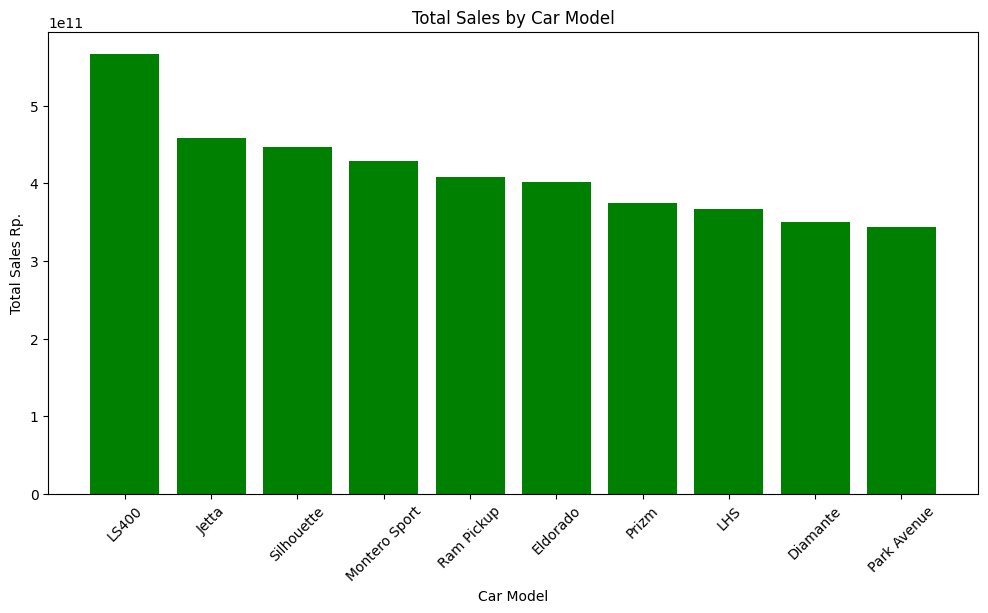

In [302]:
# Market analysis
import matplotlib.pyplot as plt

# Sum of top 10 sales by Car Model & Company
sales_by_model = df.groupby(['Model', 'Company'])['Sales'].sum().reset_index()
sales_by_model = sales_by_model.sort_values(by='Sales', ascending=False)
sales_by_model = sales_by_model.head(10)
plt.figure(figsize=(12, 6))
plt.bar(sales_by_model['Model'], sales_by_model['Sales'], color='green')
plt.xticks(rotation=45)
plt.title('Total Sales by Car Model')
plt.xlabel('Car Model')
plt.ylabel('Total Sales Rp.')